
Covariance BEFORE whitening:
[[0.18  0.134 0.078 0.034]
 [0.134 0.17  0.099 0.049]
 [0.078 0.099 0.158 0.085]
 [0.034 0.049 0.085 0.156]]

Covariance AFTER z-scoring:
[[1.    0.767 0.465 0.205]
 [0.767 1.    0.605 0.302]
 [0.465 0.605 1.    0.544]
 [0.205 0.302 0.544 1.   ]]

Covariance AFTER whitening:
[[ 1.  0.  0. -0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [-0.  0.  0.  1.]]


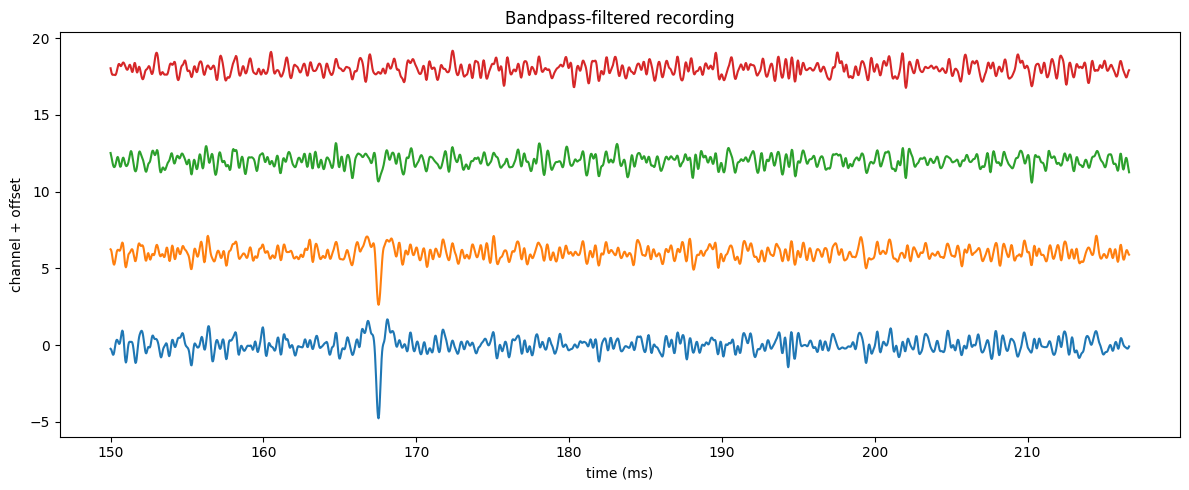

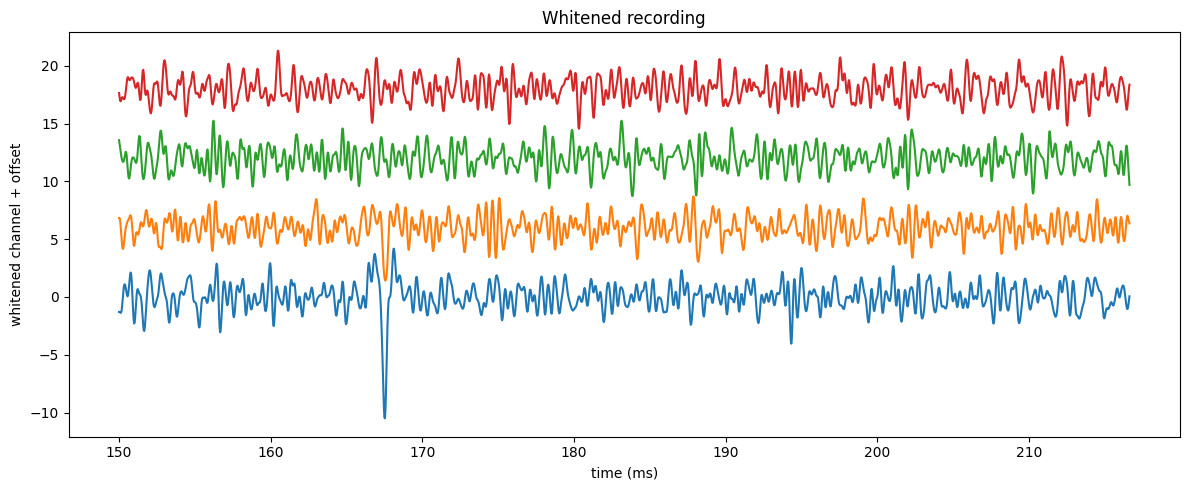

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt

np.random.seed(7)

# ============================================================
# SECTION 9 NEUROSYSTEMS
# Ticket BCI-005
# Clean correlated multichannel electrode noise
# ============================================================

fs = 30_000             # 30 kHz
duration = 2.0
T = int(fs * duration)
N = 4                   # four electrode channels

time = np.arange(T) / fs


# ============================================================
# 1. SIMULATE CORRELATED ELECTRODE NOISE
# ============================================================

# Desired cross-channel noise covariance
Sigma_true = np.array([
    [1.00, 0.75, 0.45, 0.20],
    [0.75, 1.00, 0.60, 0.30],
    [0.45, 0.60, 1.00, 0.55],
    [0.20, 0.30, 0.55, 1.00],
])

# Independent Gaussian noise
epsilon = np.random.randn(T, N)

# Cholesky factor:
# Sigma = L L^T
L = np.linalg.cholesky(Sigma_true)

# Mix independent noise to create correlated noise
noise = epsilon @ L.T


# ============================================================
# 2. ADD SLOW LFP-LIKE FLUCTUATIONS
# ============================================================

slow = (
    3.0 * np.sin(2 * np.pi * 10 * time)
    + 1.5 * np.sin(2 * np.pi * 35 * time)
)

# Different amplitude on each channel
slow_weights = np.array([1.0, 0.8, 1.2, 0.5])

raw = noise + slow[:, None] * slow_weights[None, :]


# ============================================================
# 3. ADD SOME SYNTHETIC SPIKES
# ============================================================

# simple negative spike waveform
spike_len = 60

u = np.arange(spike_len)

waveform = -6.0 * np.exp(
    -0.5 * ((u - 25) / 5.0)**2
)

# one neuron appears differently on each channel
channel_pattern = np.array([1.0, 0.7, 0.3, 0.1])

spike_times = np.array([
    5000,
    12000,
    22000,
    35000,
    47000,
    55000,
])

for t0 in spike_times:

    raw[
        t0:t0 + spike_len,
        :
    ] += waveform[:, None] * channel_pattern[None, :]


# ============================================================
# 4. BANDPASS FILTER
# ============================================================

# ML4ND motivates roughly the spike band:
# 300--3000 Hz

sos = butter(
    N=3,
    Wn=[300, 3000],
    btype="bandpass",
    fs=fs,
    output="sos"
)

Y = sosfiltfilt(
    sos,
    raw,
    axis=0
)

# Numerical centering
Y = Y - Y.mean(axis=0, keepdims=True)


# ============================================================
# 5. EMPIRICAL COVARIANCE
# ============================================================

Sigma_hat = (
    Y.T @ Y
) / T

print("\nCovariance BEFORE whitening:")
print(np.round(Sigma_hat, 3))


# ============================================================
# 6. Z-SCORE EACH CHANNEL
# ============================================================

Y_z = Y / Y.std(
    axis=0,
    keepdims=True
)

Sigma_z = (
    Y_z.T @ Y_z
) / T

print("\nCovariance AFTER z-scoring:")
print(np.round(Sigma_z, 3))


# ============================================================
# 7. WHITEN
# ============================================================

# Because covariance is symmetric PSD:
#
# Sigma = V diag(lambda) V^T

eigenvalues, V = np.linalg.eigh(Sigma_hat)

# Protect against tiny numerical eigenvalues
eps = 1e-8

inv_sqrt_eigenvalues = 1.0 / np.sqrt(
    eigenvalues + eps
)

Sigma_inv_sqrt = (
    V
    @ np.diag(inv_sqrt_eigenvalues)
    @ V.T
)

Y_white = Y @ Sigma_inv_sqrt


# ============================================================
# 8. VERIFY
# ============================================================

Sigma_white = (
    Y_white.T @ Y_white
) / T

print("\nCovariance AFTER whitening:")
print(np.round(Sigma_white, 3))


# ============================================================
# 9. VISUALIZE
# ============================================================

show = slice(4500, 6500)

plt.figure(figsize=(12, 5))

for n in range(N):
    plt.plot(
        time[show] * 1000,
        Y[show, n] + n * 6
    )

plt.xlabel("time (ms)")
plt.ylabel("channel + offset")
plt.title("Bandpass-filtered recording")

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

for n in range(N):
    plt.plot(
        time[show] * 1000,
        Y_white[show, n] + n * 6
    )

plt.xlabel("time (ms)")
plt.ylabel("whitened channel + offset")
plt.title("Whitened recording")

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

np.random.seed(7)

# ============================================================
# SECTION 9 NEUROSYSTEMS
# Ticket BCI-006
# Detect spikes in whitened multichannel voltage
# ============================================================

fs = 30_000
duration = 1.0

T = int(fs * duration)
N = 4

time = np.arange(T) / fs


# ------------------------------------------------------------
# 1. SIMULATE WHITENED BACKGROUND NOISE
#
# Here we deliberately generate independent unit-variance noise.
# This is synthetic; whitening itself would only guarantee
# covariance ~ I, not Gaussianity.
# ------------------------------------------------------------

Y_white = np.random.randn(T, N)


# ------------------------------------------------------------
# 2. CREATE A MULTICHANNEL SPIKE TEMPLATE
# ------------------------------------------------------------

D = 60
u = np.arange(D)

base_waveform = -7.0 * np.exp(
    -0.5 * ((u - 30) / 4.0)**2
)

channel_pattern = np.array([
    1.0,
    0.7,
    0.35,
    0.15
])

template = (
    base_waveform[:, None]
    * channel_pattern[None, :]
)


# ------------------------------------------------------------
# 3. INSERT SPIKES
# ------------------------------------------------------------

true_spike_times = np.array([
    4000,
    9000,
    15000,
    22000,
    27000
])

half = D // 2

for t in true_spike_times:

    start = t - half
    stop = start + D

    Y_white[start:stop] += template


# ------------------------------------------------------------
# 4. COLLAPSE CHANNELS INTO A DETECTION SCORE
#
# A spike only needs to be strongly negative on ONE channel.
#
# min across channels:
#     [-0.4, -5.3, -1.2, 0.1] -> -5.3
#
# negate it:
#     5.3
#
# Now a negative spike becomes a positive peak.
# ------------------------------------------------------------

detection_score = -Y_white.min(axis=1)


# ------------------------------------------------------------
# 5. FIND LARGE, WELL-SEPARATED PEAKS
# ------------------------------------------------------------

threshold = 4.0

refractory_ms = 3.0

min_distance = int(
    refractory_ms / 1000 * fs
)

detected_spike_times, properties = find_peaks(
    detection_score,
    height=threshold,
    distance=min_distance
)


# ------------------------------------------------------------
# 6. REMOVE EVENTS TOO CLOSE TO RECORDING BOUNDARIES
#
# Otherwise we cannot extract a full D-sample waveform.
# ------------------------------------------------------------

valid = (
    (detected_spike_times >= half)
    &
    (detected_spike_times < T - half)
)

detected_spike_times = detected_spike_times[valid]


# ------------------------------------------------------------
# 7. EXTRACT MULTICHANNEL WAVEFORMS
# ------------------------------------------------------------

waveforms = []

for t in detected_spike_times:

    X_s = Y_white[
        t - half:
        t + half,
        :
    ]

    waveforms.append(X_s)

waveforms = np.stack(waveforms)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("True spike times:")
print(true_spike_times)

print("\nDetected spike times:")
print(detected_spike_times)

print("\nNumber detected:")
print(len(detected_spike_times))

print("\nWaveform tensor shape:")
print(waveforms.shape)

True spike times:
[ 4000  9000 15000 22000 27000]

Detected spike times:
[ 3998  6376  9001 11307 15000 17179 22001 23762 27000]

Number detected:
9

Waveform tensor shape:
(9, 60, 4)


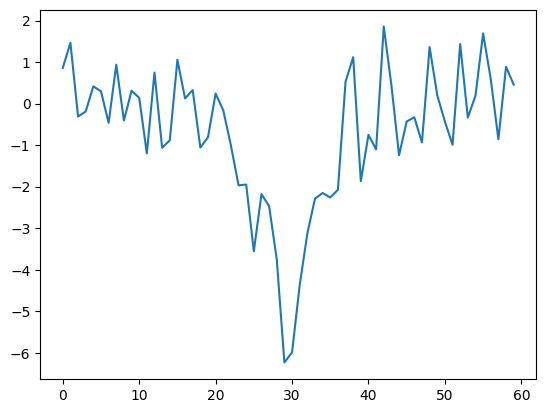

In [13]:
plt.plot(waveforms[4,:,1])

Original waveform shape:
(500, 50, 4)

Flattened matrix shape:
(500, 200)

Iterations:
4

Recovered mixing probabilities:
[0.394 0.606]

Recovered noise SD:
0.695359010929655

Clustering accuracy:
1.0


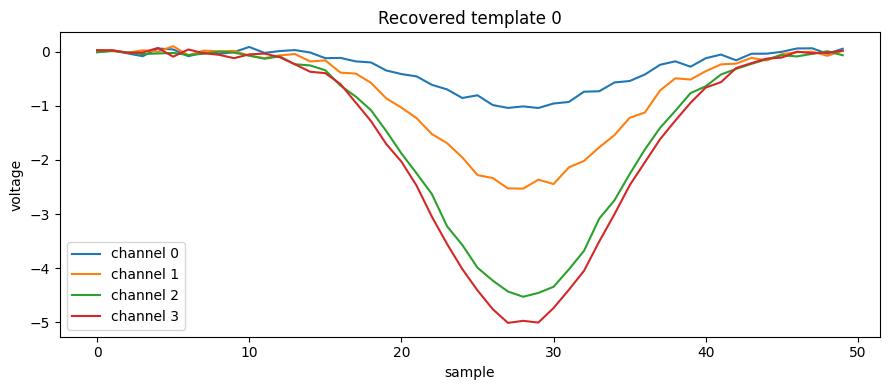

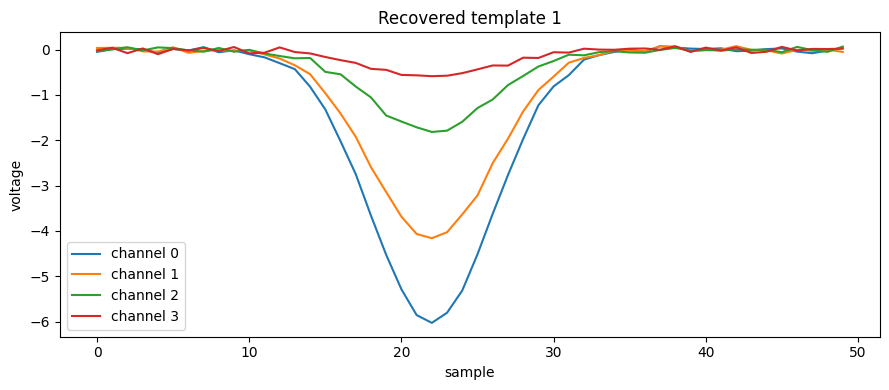

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

np.random.seed(7)

# ============================================================
# SECTION 9 NEUROSYSTEMS
# Ticket BCI-007
# Probabilistic spike sorting
# ============================================================

S = 500       # number of detected spikes
D = 50        # time samples per waveform
N = 4         # electrode channels
K = 2         # neurons

P = D * N     # flattened dimensionality


# ------------------------------------------------------------
# 1. CREATE TWO TRUE NEURAL TEMPLATES
# ------------------------------------------------------------

t = np.arange(D)

base0 = -6 * np.exp(
    -0.5 * ((t - 22) / 4)**2
)

base1 = -5 * np.exp(
    -0.5 * ((t - 28) / 6)**2
)

channel_pattern0 = np.array([1.0, 0.7, 0.3, 0.1])
channel_pattern1 = np.array([0.2, 0.5, 0.9, 1.0])

template0 = (
    base0[:, None]
    * channel_pattern0[None, :]
)

template1 = (
    base1[:, None]
    * channel_pattern1[None, :]
)

true_templates = np.stack([
    template0,
    template1
])


# ------------------------------------------------------------
# 2. SAMPLE TRUE NEURON IDENTITIES
# ------------------------------------------------------------

true_pi = np.array([0.6, 0.4])

z_true = np.random.choice(
    K,
    size=S,
    p=true_pi
)


# ------------------------------------------------------------
# 3. GENERATE NOISY WAVEFORMS
# ------------------------------------------------------------

noise_sd = 0.7

waveforms = np.empty((S, D, N))

for s in range(S):

    waveforms[s] = (
        true_templates[z_true[s]]
        +
        noise_sd * np.random.randn(D, N)
    )


# ------------------------------------------------------------
# 4. FLATTEN
#
# S x D x N
# becomes
# S x (D*N)
# ------------------------------------------------------------

X = waveforms.reshape(S, -1)

print("Original waveform shape:")
print(waveforms.shape)

print("\nFlattened matrix shape:")
print(X.shape)


# ============================================================
# 5. INITIALIZE GAUSSIAN MIXTURE
# ============================================================

# Pick two observed waveforms as rough initial templates
means = X[
    np.random.choice(S, K, replace=False)
].copy()

pi = np.ones(K) / K

sigma2 = 2.0


# ------------------------------------------------------------
# Gaussian log probability with covariance sigma^2 I
# ------------------------------------------------------------

def gaussian_log_prob(X, mean, sigma2):

    diff = X - mean

    squared_distance = np.sum(
        diff**2,
        axis=1
    )

    return (
        -0.5 * P * np.log(2 * np.pi * sigma2)
        -0.5 * squared_distance / sigma2
    )


# ============================================================
# 6. EM
# ============================================================

for iteration in range(100):

    # --------------------------------------------------------
    # E STEP
    #
    # log p(z=k, x)
    # =
    # log pi_k + log N(x | mu_k, sigma^2 I)
    # --------------------------------------------------------

    log_joint = np.zeros((S, K))

    for k in range(K):

        log_joint[:, k] = (
            np.log(pi[k])
            +
            gaussian_log_prob(
                X,
                means[k],
                sigma2
            )
        )

    # Normalize over possible neurons
    log_norm = logsumexp(
        log_joint,
        axis=1,
        keepdims=True
    )

    log_r = log_joint - log_norm

    responsibilities = np.exp(log_r)


    # --------------------------------------------------------
    # M STEP
    # --------------------------------------------------------

    Nk = responsibilities.sum(axis=0)

    new_pi = Nk / S

    new_means = (
        responsibilities.T @ X
    ) / Nk[:, None]


    # Estimate shared noise variance
    total_weighted_error = 0

    for k in range(K):

        diff = X - new_means[k]

        squared_error = np.sum(
            diff**2,
            axis=1
        )

        total_weighted_error += np.sum(
            responsibilities[:, k]
            * squared_error
        )

    new_sigma2 = (
        total_weighted_error
        / (S * P)
    )


    # convergence
    change = np.max(
        np.abs(new_means - means)
    )

    means = new_means
    pi = new_pi
    sigma2 = new_sigma2

    if change < 1e-7:
        break


print("\nIterations:")
print(iteration + 1)

print("\nRecovered mixing probabilities:")
print(pi)

print("\nRecovered noise SD:")
print(np.sqrt(sigma2))


# ------------------------------------------------------------
# 7. HARD NEURON ASSIGNMENTS
# ------------------------------------------------------------

z_hat = np.argmax(
    responsibilities,
    axis=1
)


# ============================================================
# 8. FIX LABEL-SWITCHING FOR EVALUATION
#
# neuron labels 0 and 1 are arbitrary.
# ============================================================

accuracy_direct = np.mean(
    z_hat == z_true
)

accuracy_swapped = np.mean(
    (1 - z_hat) == z_true
)

accuracy = max(
    accuracy_direct,
    accuracy_swapped
)

print("\nClustering accuracy:")
print(accuracy)


# ============================================================
# 9. RESHAPE RECOVERED MEANS BACK INTO WAVEFORMS
# ============================================================

recovered_templates = means.reshape(
    K,
    D,
    N
)


# ------------------------------------------------------------
# VISUALIZE RECOVERED TEMPLATES
# ------------------------------------------------------------

for k in range(K):

    plt.figure(figsize=(9, 4))

    for n in range(N):

        plt.plot(
            recovered_templates[k, :, n],
            label=f"channel {n}"
        )

    plt.title(
        f"Recovered template {k}"
    )

    plt.xlabel("sample")
    plt.ylabel("voltage")

    plt.legend()
    plt.tight_layout()
    plt.show()